# Feature Engineering
### **Mohon membaca setiap instruksi dan tag komentar dengan saksama sebelum melanjutkan pengerjaan.**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split

# Scalling untuk MinMax Scaller
from sklearn.preprocessing import MinMaxScaler
# Set the maximum number of columns and rows to display to a large number
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# B. Outlier Handling

### Outlier Handling : InterQuartile Handling

In [2]:
# untuk plot Q-Q
import scipy.stats as stats

In [4]:
df_california = pd.read_csv('california_dataset.csv')
df_california.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,house_price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [5]:
from sklearn.model_selection import train_test_split
# splitting terlebih dahulu
train_clfr, test_clfr = train_test_split(
    df_california,
    test_size=0.2,
    random_state=42
)

#NOTES :
#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)
#data train di-handling outliernya
#tapi tidak untuk data test, karena data test ibarat representasi data masa depan yang digunakan untuk melihat performa Machine Learning

### Assignment 1.a :
1. lakukan looping untuk melihat plot distribusi data dan outlier pada kolom-kolom : ['MedInc', 'HouseAge', 'AveRooms','AveBedrms', 'AveOccup'] di california_dataset.csv
2. Daftar nama kolom yang Anda cek, kolom_kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

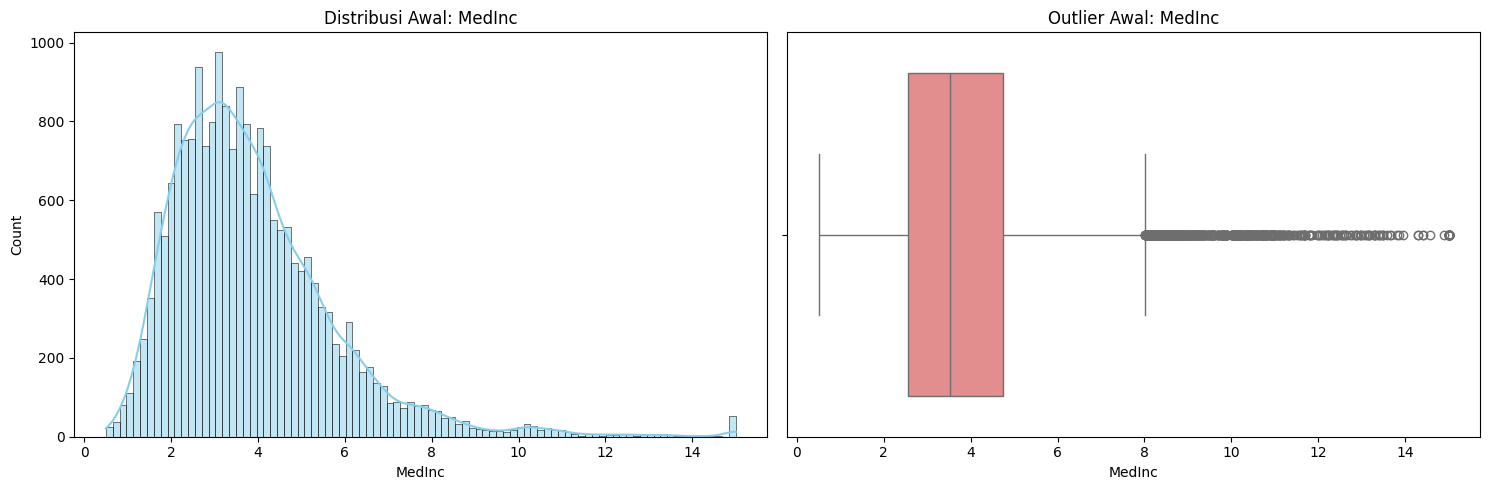

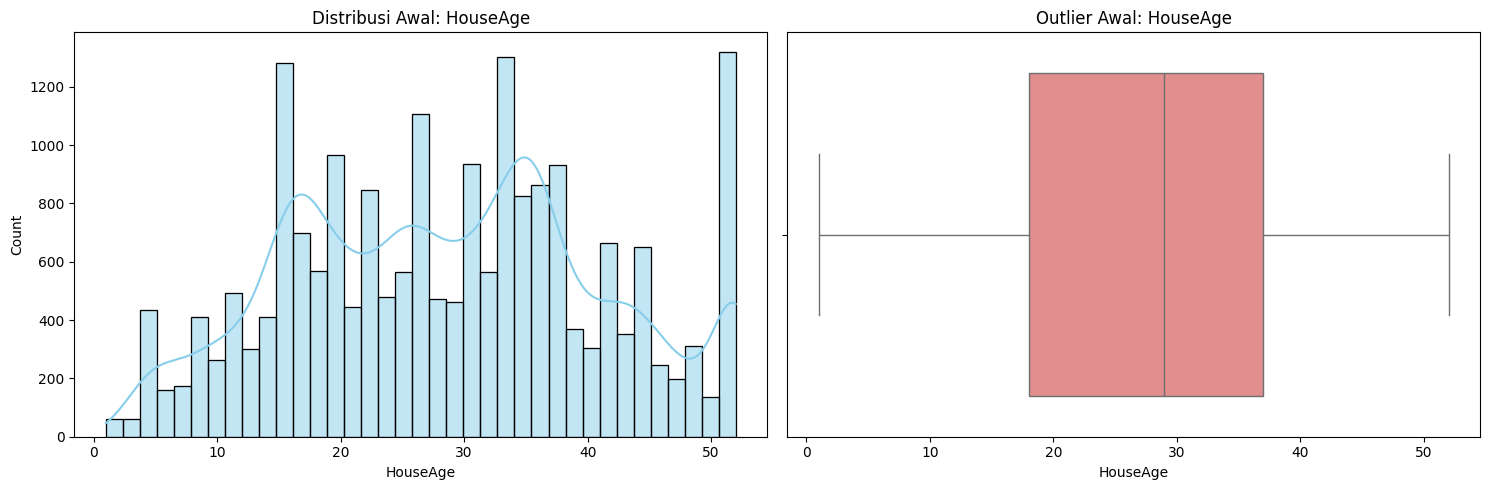

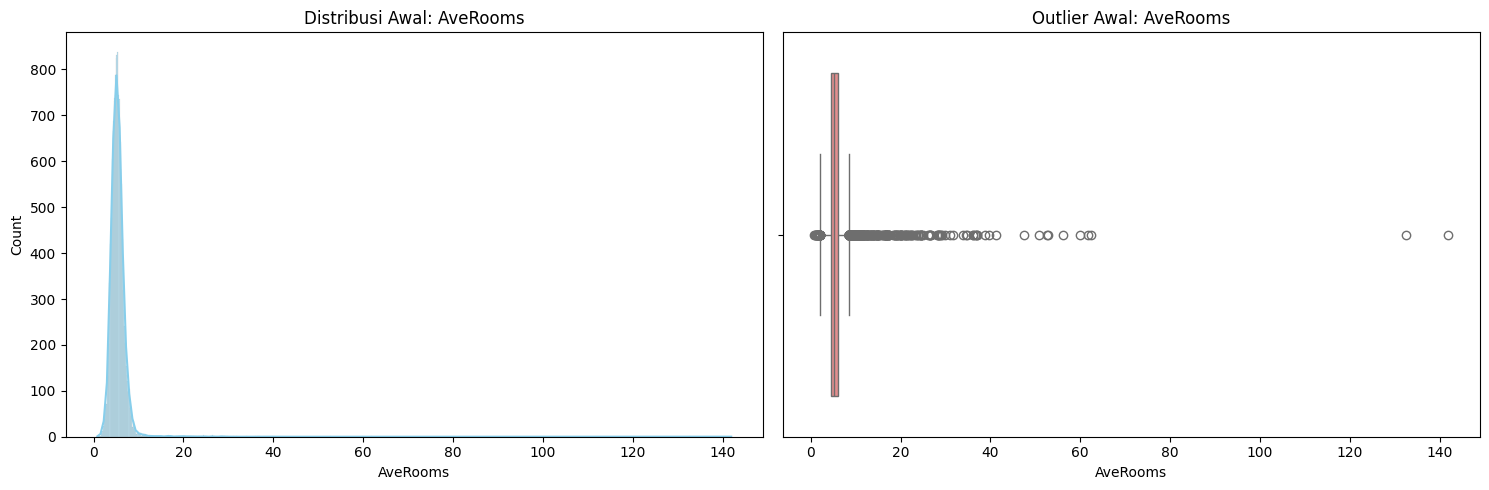

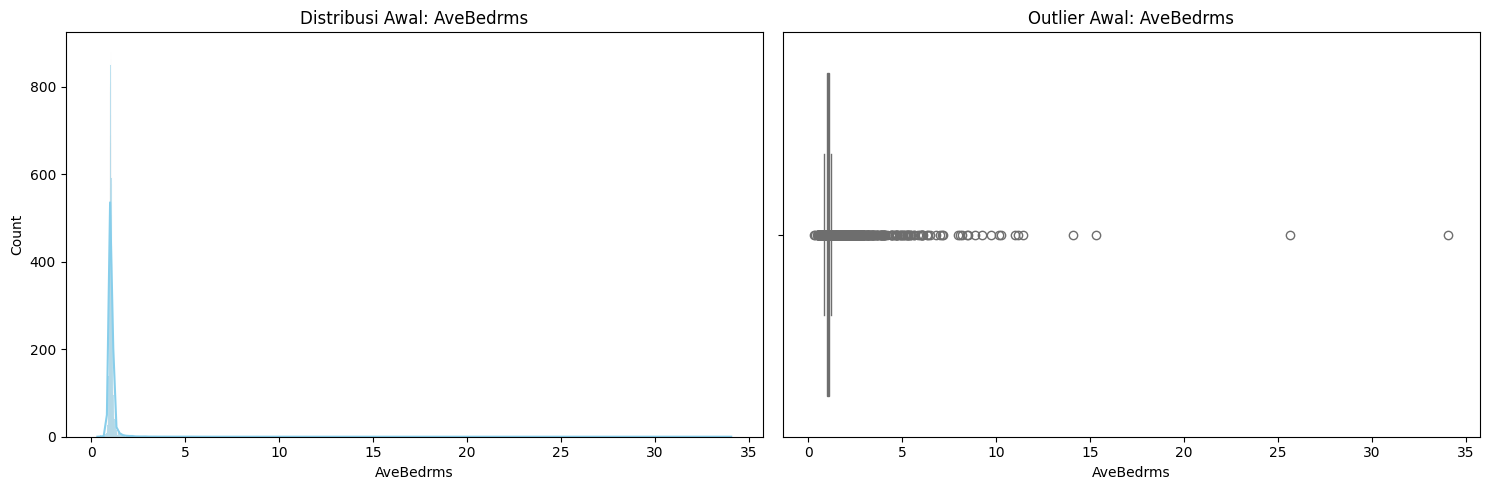

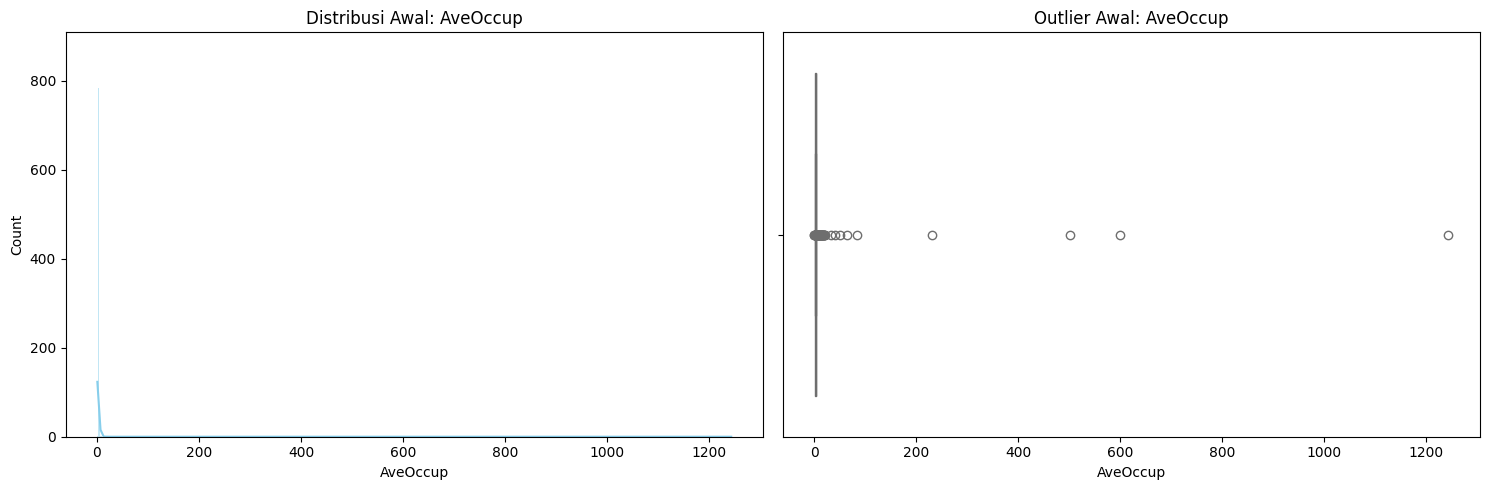

In [6]:
# Assignment 1.a : lakukan looping untuk melihat plot distribusi data dan outlier pada kolom-kolom : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup'] di california_dataset.csv
# Daftar nama kolom yang ingin Anda cek
kolom_kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

for kolom in kolom_kolom:
    plt.figure(figsize=(15, 5))
    
    # Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(df_california[kolom], kde=True, color='skyblue')
    plt.title(f'Distribusi Awal: {kolom}')
    
    # Boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df_california[kolom], color='lightcoral')
    plt.title(f'Outlier Awal: {kolom}')
    
    plt.tight_layout()
    plt.show()


### Assignment 1.b
1. Lakukan handling outlier pilih 1 kolom saja yang di handling dengan IQR setelah mengecek distribusinya
2. Dan cek distribusinya kembali

In [8]:
### Assignment 1.b Lakukan handling outlier pilih 1 kolom saja yang di handling dengan IQR setelah mengecek distribusinya
### Dan cek distribusinya kembali

kolom_pilihan = 'AveBedrms'

# Hitung IQR
Q1 = df_california[kolom_pilihan].quantile(0.25)
Q3 = df_california[kolom_pilihan].quantile(0.75)
IQR = Q3 - Q1

# Tentukan Batas
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

# Eksekusi Handling (Hapus Outlier)
df_final = df_california[(df_california[kolom_pilihan] >= lower_limit) & (df_california[kolom_pilihan] <= upper_limit)]

print(f"Handling selesai! Data berkurang dari {len(df_california)} menjadi {len(df_final)} baris.")

Handling selesai! Data berkurang dari 20640 menjadi 19216 baris.


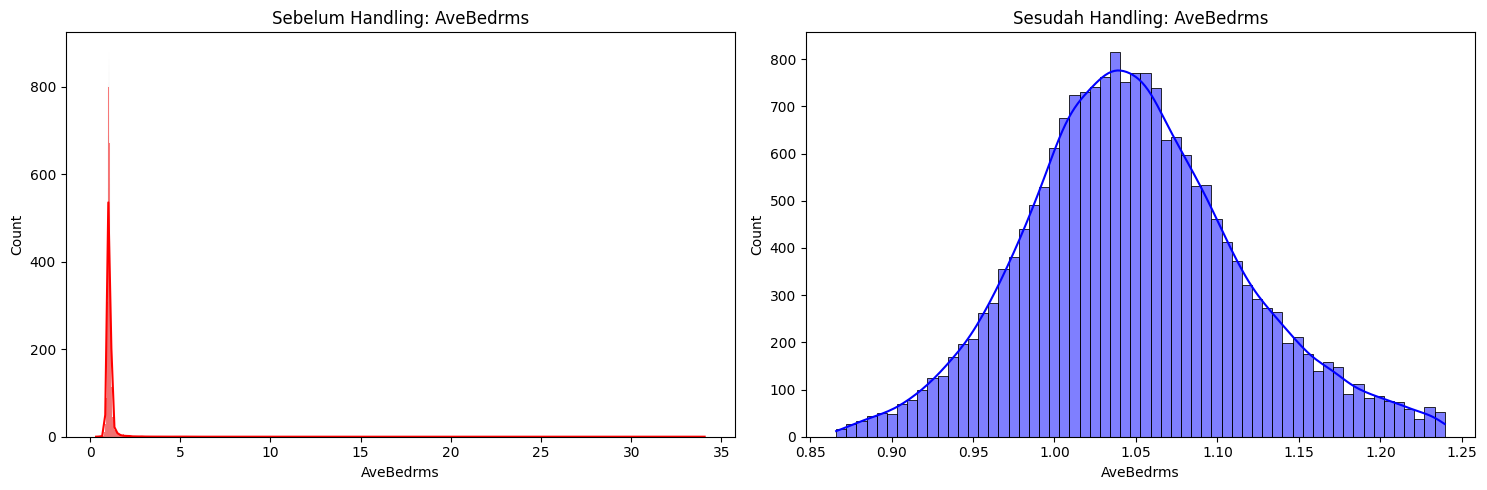

In [10]:
# Melakukan loop untuk mengecek distribusi tiap kolom
plt.figure(figsize=(15, 5))

# Sebelum
plt.subplot(1, 2, 1)
sns.histplot(df_california[kolom_pilihan], kde=True, color='red')
plt.title(f'Sebelum Handling: {kolom_pilihan}')

# Sesudah
plt.subplot(1, 2, 2)
sns.histplot(df_final[kolom_pilihan], kde=True, color='blue')
plt.title(f'Sesudah Handling: {kolom_pilihan}')

plt.tight_layout()
plt.show()

# C. Missing Value Handling
Missing Value Merupakan nilai yang hilang di suatu kolom, namun tidak hanya sebatas itu. Untuk nilai yang tidak sesuai tapi muncul didalam suatu kolom tertentu juga bisa dianggap sebagai missing value. Misal tipenya kategorikal tapi isinya ada yang berupa angka dan juga sebaliknya.

In [14]:
df_company = pd.read_csv('company.csv')
print(df_company.columns.tolist())

['Revenue', 'Size', 'Rating', 'Headquarters']


### Aturan missing value handling :
1. jika tipe datanya itu **numerik** -> handling menggunakan **median** (robust / tahan terhadap outlier)
2. jika tipe datanya itu **kategorik / object / string** -> handling menggunakan **mode / modus**

In [15]:
from sklearn.model_selection import train_test_split
#Splitting terlebih dahulu
X = df_company.drop(columns=['Revenue']) 
y = df_company['Revenue']

# 2. Lakukan Splitting data (Sesuai aturan 80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Menampilkan informasi hasil split
print(f"Jumlah baris Data Train (80%): {len(X_train)}")
print(f"Jumlah baris Data Test  (20%): {len(X_test)}")
#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)

Jumlah baris Data Train (80%): 537
Jumlah baris Data Test  (20%): 135


## Assignment 2. Missing Value Handling :
1. Cek persentase missing value pada kolom Headquarters di company.csv, Cek jenis missing valuenya ?
2. apakah di drop atau tidak (gunakan syarat drop kolom jika > 20%)
3. jika tidak maka handling, dan dengan cara apa handling nilainya, median atau modus ?

In [17]:
#Tulis jawaban missing value handling kolom Headquarters disini
null_count = df_company['Headquarters'].isnull().sum()
persentase = (null_count / len(df_company)) * 100

print(f"Jumlah Missing Value di Headquarters: {null_count}")
print(f"Persentase Missing Value: {persentase:.2f}%")

# 2. Syarat Drop (Cek apakah > 20%)
if persentase > 20:
    print("Kesimpulan: Persentase > 20%, maka kolom sebaiknya di-DROP.")
else:
    print("Kesimpulan: Persentase <= 20%, maka kolom TIDAK di-drop (Lakukan Imputasi).")

Jumlah Missing Value di Headquarters: 0
Persentase Missing Value: 0.00%
Kesimpulan: Persentase <= 20%, maka kolom TIDAK di-drop (Lakukan Imputasi).


In [18]:
# 3. Handling Nilai (Menggunakan Modus karena Headquarters adalah data Kategorik)
# Kita ambil nilai yang paling sering muncul
modus_hq = df_company['Headquarters'].mode()[0]

# Isi nilai yang kosong (NaN) dengan nilai modus tersebut
df_company['Headquarters'] = df_company['Headquarters'].fillna(modus_hq)

# Verifikasi hasil
print(f"Missing value telah diisi dengan modus: {modus_hq}")
print(f"Jumlah missing value sekarang: {df_company['Headquarters'].isnull().sum()}")

Missing value telah diisi dengan modus: New York, NY
Jumlah missing value sekarang: 0


# D. Encoding
Definisi : Mengubah tipe kategorikal menjadi numerikal dengan pendekatan aturan encoding untuk persiapan sebelum dilakukannya machine learning modelling. Teknik Encoding yang umum dipakai :
1. One Hot Encoding (OHE) : Lakukan pada kolom gender
2. Label Encoding / Ordinal Encoding : Lakukan pada kolom Yes dan No, Jika Yes menjadi 1 , Jika No menjadi 0. Sebagai Contohnya di kolom  Partner, Dependents.
3. Mean Encoding : Contract

In [20]:
df_churn = pd.read_csv('TelcoCustomerChurn.csv')

In [24]:
#Splitting terlebih dahulu
X = df_churn.drop(columns=['Churn'])
y = df_churn['Churn']

# Splitting data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Data berhasil di-split. Jumlah X_train: {len(X_train)}")

Data berhasil di-split. Jumlah X_train: 5634


In [25]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# --- 1. One Hot Encoding (OHE) pada kolom 'gender' ---
X_train = pd.get_dummies(X_train, columns=['gender'])
X_test = pd.get_dummies(X_test, columns=['gender'])

# --- 2. Label Encoding pada kolom 'Partner' dan 'Dependents' ---
# Yes jadi 1, No jadi 0
mapping_yes_no = {'Yes': 1, 'No': 0}
for col in ['Partner', 'Dependents']:
    X_train[col] = X_train[col].map(mapping_yes_no)
    X_test[col] = X_test[col].map(mapping_yes_no)

# --- 3. Mean Encoding pada kolom 'Contract' ---
# Menghitung rata-rata target (y_train) berdasarkan kategori 'Contract'
# Kita perlu gabungkan sementara X_train dan y_train untuk menghitung mean
temp_df = X_train.copy()
temp_df['target_numeric'] = y_train.map({'Yes': 1, 'No': 0})
mean_map = temp_df.groupby('Contract')['target_numeric'].mean()

# Terapkan hasil perhitungan train ke data train dan test
X_train['Contract'] = X_train['Contract'].map(mean_map)
X_test['Contract'] = X_test['Contract'].map(mean_map)

print("Encoding Selesai!")
X_train[['Partner', 'Dependents', 'Contract']].head()

Encoding Selesai!


,Partner,Dependents,Contract
2142,0,1,0.117987
1623,0,0,0.028379
6074,1,0,0.426533
1362,0,0,0.426533
6754,0,1,0.028379


## Assignment 3.a Label Encoder :
1. Pilih kolom-kolom StreamingMovies, StreamingTV, TechSupport, DeviceProtection, OnlineBackup, OnlineSecurity, MultipleLines
2. Ganti nilai yang tidak sesuai : No internet service menjadi No lalu validasi dengan value_counts
3. Kemudian lakukan label Encoder
4. Notes : gunakan Telco-Customer-Churn.csv

In [27]:
#Tulis jawaban
from sklearn.preprocessing import LabelEncoder

# 1. Pilih kolom-kolom sesuai instruksi
kolom_label = [
    'StreamingMovies', 'StreamingTV', 'TechSupport', 'DeviceProtection', 
    'OnlineBackup', 'OnlineSecurity', 'MultipleLines'
]

# 2. Ganti nilai 'No internet service' dan 'No phone service' menjadi 'No'
for col in kolom_label:
    X_train[col] = X_train[col].replace({'No internet service': 'No', 'No phone service': 'No'})
    X_test[col] = X_test[col].replace({'No internet service': 'No', 'No phone service': 'No'})

# Validasi dengan value_counts pada salah satu kolom
print("Hasil validasi kolom StreamingMovies:")
print(X_train['StreamingMovies'].value_counts())


Hasil validasi kolom StreamingMovies:
StreamingMovies
No     3437
Yes    2197
Name: count, dtype: int64


In [28]:
le = LabelEncoder()

for col in kolom_label:
    # Kita gunakan fit pada train, lalu transform ke train dan test
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])



In [29]:
print("Label Encoding selesai untuk semua kolom.")

Label Encoding selesai untuk semua kolom.


In [30]:
# Menampilkan hasil akhir
X_train[kolom_label].head()

,StreamingMovies,StreamingTV,TechSupport,DeviceProtection,OnlineBackup,OnlineSecurity,MultipleLines
2142,1,0,0,1,0,1,0
1623,1,1,0,0,1,0,1
6074,0,0,0,0,0,0,0
1362,0,0,0,0,0,0,0
6754,0,0,1,0,1,1,1


## Selesai :)